# analyse base Rystad puis premiers modèles Julia/Pytorch



dataset très lourds, quelques astuces: nrows, usecols=[''], charger des string en category, nombres en float32 si la précision n'est pas requise encore, avec dtype={'Production':'float32'} 

chunk_iterator = pd.read_csv('.../Production.csv', chunksize=10000)
for chunk in chunk_iterator:
    # Traitement vectorisé sur le chunk (ex: agrégation, filtrage)
    pass


Migrer sur Polars pour le multithreading?

#### problèmes (réglés): 
* clés RE_ID en doublons ? 
* problèmes de décimales ',' et '.', séparation ; ou , 

In [16]:
import pandas as pd, numpy as np
from pathlib import Path

DATA = Path("/Users/rratajczyk/Desktop/OilMarket/local/Data")

Oil_Definition = ["Bitumen","Extra Heavy Oil","Heavy Oil 15-19",
                  "Heavy Oil 20-22","Sour (> 3%)","Regular","Light","Condensate","Synthetic crude"]#,"NGL"]# pourquoi NGL est dans Oil_Definition ? c'est du gaz, pas du pétrole. Et synthetic crude: double comptage avec bitumen, produit secondaire du traitement du bitume. (à voir la définition dans Rystad)
Gas_Definition = ["Gas","LNG","Feed gas to LNG","Feed gas to Pipeline","Gas in Pipelines","GTL"]

def to_num(s):
    # dans les colonnes numériques la virgule est toujours décimale, et aucun séparateur de milliers 
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False),
                         errors="coerce").round(6)

def load(name, numeric_cols=()):
    df = pd.read_csv(DATA / name, encoding="latin-1", low_memory=False)
    for c in numeric_cols:
        if c in df.columns:
            df[c] = to_num(df[c])
    return df

eco_cols = ["Free Cash Flow","Royalty effects","Income Tax","Well Capex","Facility Capex",
            "Exploration Well Capex","G&G and Seismic capex","SG&A Opex","Transportation Opex",
            "Production Opex","Abandonment cost","Sum","Government Profit Oil","Lease Capex","Taxes Opex"]
res_cols = ["Resources (Million bbl)","1P Reserves (Million bbl)",
            "2P Reserves (Million bbl)","Technical recoverable resources (Million bbl)"]

asset    = load("Asset_Info.csv").drop_duplicates("RE ID")
prod     = load("Production.csv", ["Production (Million bbl)"])
reserves = pd.concat([load("Reserves_North_America.csv", res_cols),
                      load("Reserves_Rest.csv",          res_cols)], ignore_index=True)
eco      = pd.concat([load("Eco_North_America.csv", eco_cols),
                      load("Eco_Rest.csv",          eco_cols)], ignore_index=True)
deflator = load("Deflator.csv", ["Economics (MUSD)","Economics (MUSD real)"])
ci       = pd.read_csv(DATA / "CI_Full.csv", low_memory=False)   # déjà UTF-8

for nm, d in [("asset",asset),("prod",prod),("reserves",reserves),
              ("eco",eco),("deflator",deflator),("ci",ci)]:
    print(f"{nm:9s} {d.shape}")





asset     (103193, 82)
prod      (8546951, 8)
reserves  (27581380, 8)
eco       (10557390, 19)
deflator  (201, 3)
ci        (57217, 25)


### voir : Figure 1: Heterogeneity in upstream and midstream carbon intensities. , Coulomb et al.
(a) Carbon-intensity-based oil supply: as of 1992
Oil type
Bitumen
60
Carbon intensity (gCO2e/MJ)
40
Condensate
Extra Heavy Oil
Heavy Oil 15−19
Heavy Oil 20−23
Light
Regular
Sour (> 3%)

In [17]:
prod.columns

Index(['RE ID', 'Asset', 'Year', 'Oil and Gas Detail', 'Data Type',
       'Data Confidence', 'Data Source', 'Production (Million bbl)'],
      dtype='str')

In [18]:
reserves['Oil and Gas Detail'].value_counts()

Oil and Gas Detail
Gas                     8658599
NGL                     5460632
Regular                 5173677
Condensate              4405232
Light                   3306642
Heavy Oil 15-19          134546
Sour (> 3%)              123826
Heavy Oil 20-22          106821
Extra Heavy Oil           61463
Bitumen                   60033
Feed gas to LNG           39509
LNG                       39509
Synthetic crude            6462
CTG                        3337
GTL                         848
Gas in Pipelines            122
Feed gas to Pipeline        122
Name: count, dtype: int64

In [19]:
COULOMB_T3 = {"Saudi Arabia":14,"Russia":12,"United States":10,"Iran":5,"China":5,
              "Mexico":4,"UAE":4,"Canada":4,"Venezuela":4,"Iraq":3,"Norway":3,
              "Kuwait":3,"Nigeria":3,"United Kingdom":2,"Brazil":2}

p = prod.copy()
p = p[p["Oil and Gas Detail"] != "Sum"]
p = p[~p["Asset"].str.contains("ther liquids|Refinery gains", na=False)]
p = p[(p["Year"] >= 1992) & (p["Year"] <= 2018)]
p = p[p["Oil and Gas Detail"].isin(Oil_Definition)]

p = p.merge(asset[["RE ID","Country"]], on="RE ID", how="left")
p["Country"] = p["Country"].replace({"Lybia":"Libya"})        # faute Rystad

# Neutral Zone -> 50/50 Saudi Arabia / Kuwait
nz = p[p["Country"] == "Neutral Zone"].copy(); nz["Production (Million bbl)"] /= 2
p = pd.concat([p[p["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

ctry = p.groupby("Country")["Production (Million bbl)"].sum()
share = (100 * ctry / ctry.sum()).round(1).sort_values(ascending=False)

cmp3 = (share.rename("nous").to_frame()
        .assign(Coulomb=lambda d: d.index.map(COULOMB_T3)))
print("TOP 15 PRODUCTION:\n", cmp3.head(15))

# écart  moyen à la table de Coulomb 
print(f"Écart moyen absolu (MAPE) : {(((cmp3.head(15)['nous'] - cmp3.head(15)['Coulomb']).abs() / cmp3.head(15)['Coulomb']).mean() * 100).round(2)} %")

TOP 15 PRODUCTION:
                 nous  Coulomb
Country                      
Saudi Arabia    12.6     14.0
Russia          12.1     12.0
United States    9.2     10.0
Iran             5.3      5.0
China            4.9      5.0
Venezuela        4.0      4.0
Mexico           3.9      4.0
Canada           3.6      4.0
UAE              3.6      4.0
Norway           3.3      3.0
Iraq             3.2      3.0
Kuwait           3.2      3.0
Nigeria          3.0      3.0
United Kingdom   2.3      2.0
Brazil           2.2      2.0
Écart moyen absolu (MAPE) : 6.51 %


## méthode de calcul: 

## $S_i = \frac{\sum_{t=1992}^{2018} q_{i,t}}{\sum_{t=1992}^{2018} Q_t}$
(notations q ou x pour l'extraction)

In [20]:
COULOMB_T5 = {"Saudi Arabia":286,"Russia":143,"United States":190,"Iran":90,"China":46,
              "Mexico":25,"UAE":72,"Canada":101,"Venezuela":34,"Iraq":122,"Norway":21,
              "Kuwait":61,"Nigeria":26,"United Kingdom":13,"Brazil":62}

r = reserves.rename(columns={"Resources (Million bbl)":"Resources",
                             "1P Reserves (Million bbl)":"Reserves_1P",
                             "2P Reserves (Million bbl)":"Reserves_2P"})
r["Oil_Gas"] = np.where(r["Oil and Gas Detail"].isin(Oil_Definition), "Oil",
               np.where(r["Oil and Gas Detail"].isin(Gas_Definition), "Gas", "Other"))
r = r[(r["Oil_Gas"] == "Oil") & (r["Year"] == 2019)]
r = (r.groupby("RE ID", as_index=False)[["Resources","Reserves_1P","Reserves_2P"]].sum()
       .merge(asset[["RE ID","Country"]], on="RE ID", how="left"))
r["Country"] = r["Country"].replace({"Lybia":"Libya"})

nz = r[r["Country"] == "Neutral Zone"].copy()
for c in ["Resources","Reserves_1P","Reserves_2P"]: nz[c] /= 2
r = pd.concat([r[r["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

out = r.groupby("Country")[["Resources","Reserves_1P","Reserves_2P"]].sum() / 1000  # -> Gb
out = out.assign(Coulomb_Resources=lambda d: d.index.map(COULOMB_T5))
print("Total monde Resources (Gb) :", round(out["Resources"].sum(), 0), " (papier ≈1518)")
print(out.loc[list(COULOMB_T5)].round(0))

Total monde Resources (Gb) : 1424.0  (papier ≈1518)
                Resources  Reserves_1P  Reserves_2P  Coulomb_Resources
Country                                                               
Saudi Arabia        245.0         56.0         90.0              286.0
Russia              141.0         49.0         76.0              143.0
United States       124.0         44.0         59.0              190.0
Iran                 91.0         16.0         30.0               90.0
China                63.0         18.0         36.0               46.0
Mexico               19.0          5.0         10.0               25.0
UAE                  76.0         18.0         32.0               72.0
Canada               87.0         37.0         56.0              101.0
Venezuela            13.0          3.0          5.0               34.0
Iraq                109.0         20.0         46.0              122.0
Norway               16.0          5.0         10.0               21.0
Kuwait               50.0

### $2P = 1P + Probable$
Pandas effectue une agrégation verticale, donc on ne mélange jamais 2P avec 1P avec Reserves par ex (jamais de double comptage). 


Coulomb et al. définissent les réserves de 2019 en sommant la trajectoire d'extraction future prévue par Rystad dans son scénario par défaut (BAU), d'aujourd'hui jusqu'en 2100.
Mathématiquement : $R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$.
Cette définition exclut alors "les ressources qui ne devraient jamais être économiquement ou techniquement récupérables"  

Je cite:   
"A country’s stranded assets are expressed as the share of its 2019 recoverable reserves
that is left underground under a specific scenario. For each field (discovered before 2019),
we compute its 2019 oil reserves as the sum of its future productions up to 2100 based on
Rystad business-as-usual (BAU) scenario, as done in the rest of the paper (see Appendices
D.1 and D.2). This reserve measure thus excludes resources that are never expected to be
economically or technically recoverable. The “stranded assets” can thus be interpreted as
the assets that become unburnable due to mitigation policy (here the joint effect of demand
drop in the future compared to a BAU and supply recomposition).20 The last column of
20The amount of oil underground exceeds the proven reserves in our analysis. But oil resources not
26
Table 5 gives the 2019 reserves by country, and global reserves of about 1,518 Gb. Overall,
our global reserves estimates are on par with those of the rest of the literature (BP, 2019;
IEA, 2019; OPEC, 2019; BGR, 2020; EIA, 2021; Welsby et al., 2021) with an average value
of 1,598 Gb, a maximum of 1,790 Gb (BGR, 2020) and a minimum of 1,276 Gb (Welsby
et al., 2021)."  

$R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$





In [21]:

print(prod['Data Type'].value_counts())
print(prod['Data Source'].value_counts())
print(prod['Year'].value_counts())


Data Type
Modeled          5580748
Sum              1993462
Researched        972733
Not Available          8
Name: count, dtype: int64
Data Source
Modeled                        5580748
Sum                            1993544
Government webpage              675269
Analyst estimate                146704
Annual Report                    60105
Other document                   53314
Company Press Releases           20213
Articles on oil&gas domains      11121
Investor Presentation             5864
Company Webpage                     46
Oilfield service Report             15
Not Available                        8
Name: count, dtype: int64
Year
2055    124954
2056    124908
2054    124666
2057    124546
2053    123909
         ...  
1904       696
1903       685
1902       632
1901       611
1900       569
Name: count, Length: 201, dtype: int64


In [22]:

p = prod[(prod["Oil and Gas Detail"].isin(Oil_Definition)) & (prod["Data Type"] != "Sum")].copy()

# CAPACITÉ : Pic historique par gisement
capa_asset = p.groupby("RE ID")["Production (Million bbl)"].max().rename("Capacity")

#  RÉSERVES BAU  : Intégrale de la production future (2019-2100) (Coulomb)
res_bau = p[p["Year"] >= 2019].groupby("RE ID")["Production (Million bbl)"].sum().rename("Reserves BAU (Million bbl)")

# Méthode STATIQUE : agrégation 2019 
r = reserves[(reserves["Oil and Gas Detail"].isin(Oil_Definition)) & (reserves["Year"] == 2019)]
cols_res = ["1P Reserves (Million bbl)", "2P Reserves (Million bbl)", "Technical recoverable resources (Million bbl)"]
res_asset = r.groupby("RE ID")[cols_res].sum()


df_assets = (res_asset
             .join(capa_asset, how="outer")
             .join(res_bau, how="outer")
             .merge(asset[["RE ID", "Country"]], on="RE ID", how="left"))

# ZONE NEUTRE (50/50)
cols_to_split = cols_res + ["Capacity", "Reserves BAU (Million bbl)"]
nz = df_assets[df_assets["Country"] == "Neutral Zone"].copy()
nz[cols_to_split] /= 2

df_assets = pd.concat([
    df_assets[df_assets["Country"] != "Neutral Zone"], 
    nz.assign(Country="Saudi Arabia"), 
    nz.assign(Country="Kuwait")
])

# Agregagatio, par pays. 
tableau_final = df_assets.groupby("Country")[cols_to_split].sum().round(2)


print(tableau_final.sort_values("Reserves BAU (Million bbl)", ascending=False).head(15))

print("Total monde Reserves BAU (Gb) :", round(tableau_final["Reserves BAU (Million bbl)"].sum() / 1000, 2), " (papier ≈1518)")

               1P Reserves (Million bbl)  2P Reserves (Million bbl)  \
Country                                                               
Saudi Arabia                    55538.82                   89728.73   
United States                   44439.41                   58670.32   
Russia                          49167.95                   75513.69   
Iraq                            19858.63                   46124.96   
Canada                          36695.55                   55521.50   
Iran                            16493.02                   30029.66   
UAE                             18315.32                   31742.79   
China                           18397.05                   35850.11   
Kuwait                          12722.02                   20826.93   
Brazil                          10446.61                   29408.76   
Kazakhstan                      14507.78                   18520.96   
Qatar                            8638.96                   15163.44   
Argent

1. La base n'exporte pas l'agrégat strict "3P". La variable Technical recoverable resources est utilisée comme proxy de la borne supérieure absolue des volumes récupérables (incluant les ressources contingentes).
2. La capacité est modélisée comme la somme des pics de production historiques des gisements du pays.

In [23]:
import matplotlib.pyplot as plt

# pour les déciles de la Figure 1b
def wquantile(values, weights, q):
    v = np.asarray(values, float); w = np.asarray(weights, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0); v, w = v[m], w[m]
    if len(v) == 0: return np.nan
    o = np.argsort(v); v, w = v[o], w[o]
    cum = (np.cumsum(w) - 0.5*w) / w.sum()
    return np.interp(q, cum, v)

# prod_w : production oil par champ sur 1992-2018 (= poids des moyennes/déciles) 
prod_w = (prod[prod["Year"].between(1992, 2018) & prod["Oil and Gas Detail"].isin(Oil_Definition)]
          .groupby("RE ID", as_index=False)["Production (Million bbl)"].sum()
          .rename(columns={"Production (Million bbl)": "prod_w"}))

print("prod_w :", prod_w.shape, "| wquantile OK")

prod_w : (22524, 2) | wquantile OK


In [24]:
# Costs_Included = Unit_Param$Costs_Included.  "coûts réels privés" (opex + capex + abandon),
# fiscalité (Royalty/Income Tax/Gvt Profit/Taxes Opex) exclue (transferts)
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]               #  USD réels déflatés
e["cost_year"] = e[Costs_Included].sum(axis=1)

cost_tot = e.groupby("RE ID")["cost_year"].sum()
oil_tot  = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
            .groupby("RE ID")["Production (Million bbl)"].sum())
cost = (cost_tot / oil_tot).rename("cost_bbl").reset_index()   #  "Average" = sum(coûts)/sum(prod)
cost = cost.replace([np.inf, -np.inf], np.nan).dropna()
if cost["cost_bbl"].median() < 0:                   
    cost["cost_bbl"] = -cost["cost_bbl"]
print(cost["cost_bbl"].describe().round(2))

count    5.278700e+04
mean     6.707513e+17
std      1.541079e+20
min     -1.072152e+09
25%      4.204000e+01
50%      9.398000e+01
75%      2.866600e+02
max      3.540695e+22
Name: cost_bbl, dtype: float64


In [25]:
print(" signe/magnitude des colonnes de coût (eco) ")
print(eco[Costs_Included].describe().T[["mean","50%","min","max"]].round(2))

oil_tot = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
           .groupby("RE ID")["Production (Million bbl)"].sum())
print("\nchamps oil_tot < 0.1 Mbbl :", int((oil_tot < 0.1).sum()), "/", len(oil_tot))

cic = (ci["CI_Final_EBA"] + ci["CI_midstream"])
print("\nCI combinée (kg/bbl) :", cic.describe().round(1).to_dict())

print("\nVenezuela - asset:", int((asset['Country']=='Venezuela').sum()),
      "| ci:", int((ci['Country']=='Venezuela').sum()))

 signe/magnitude des colonnes de coût (eco) 
                         mean   50%  min        max
Production Opex          5.51  0.04 -0.0   17569.51
Transportation Opex      3.19  0.02 -0.0   11178.16
SG&A Opex                3.05  0.02 -0.0   10468.30
Well Capex              29.56  0.17 -0.0  122579.50
Facility Capex          11.75  0.15 -0.0   46990.64
Exploration Well Capex   7.02  0.00 -0.0    2927.00
G&G and Seismic capex    0.45  0.04  0.0    2361.26
Abandonment cost         1.70  0.00 -0.0    9503.23

champs oil_tot < 0.1 Mbbl : 18295 / 58800

CI combinée (kg/bbl) : {'count': 57217.0, 'mean': 139.9, 'std': 3528.6, 'min': 46.5, '25%': 62.8, '50%': 70.1, '75%': 82.3, 'max': 627771.9}

Venezuela - asset: 667 | ci: 527


In [26]:
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
e[Costs_Included] = e[Costs_Included].fillna(0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]
cost_tot = e.groupby("RE ID")[Costs_Included].sum().sum(axis=1)

g = prod[prod["Oil and Gas Detail"].isin(Oil_Definition + Gas_Definition)].copy()
g["is_oil"] = g["Oil and Gas Detail"].isin(Oil_Definition)
tot  = g.groupby("RE ID")["Production (Million bbl)"].sum()
oilp = g[g["is_oil"]].groupby("RE ID")["Production (Million bbl)"].sum()

cost = pd.DataFrame({"cost_tot": cost_tot}).join(tot.rename("tot")).join(oilp.rename("oil_tot"))
cost = cost[cost["oil_tot"].fillna(0) >= 0.1]            # vire les champs ~sans oil (division explosive)
cost["cost_bbl"] = cost["cost_tot"] / cost["tot"]        # coûts / production totale (boe) = part oil imputée
cost = cost.replace([np.inf,-np.inf], np.nan).dropna(subset=["cost_bbl"]).reset_index()
print(cost["cost_bbl"].describe().round(2))

count    40495.00
mean        63.83
std        341.40
min          2.05
25%         22.65
50%         33.81
75%         54.44
max      21339.20
Name: cost_bbl, dtype: float64


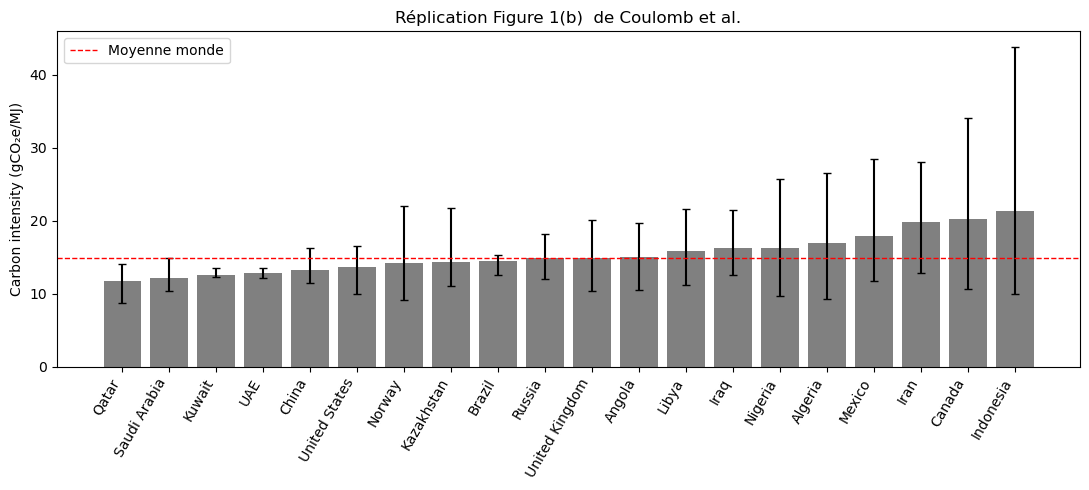

In [27]:
ci2 = ci.rename(columns={"REID":"RE ID"})
UP, MID = "CI_Final_EBA", "CI_midstream"
MJ_PER_BBL = 6120.0

d = (ci2[["RE ID", UP, MID]].dropna()
     .assign(CI_comb=lambda x: x[UP] + x[MID])
     .merge(asset[["RE ID","Country"]], on="RE ID", how="left")
     .merge(prod_w, on="RE ID", how="left"))
d = d[d["CI_comb"] < 300]                         # CI extrêmes 
d["Country"] = d["Country"].replace({"Lybia":"Libya"})
d = d.dropna(subset=["Country","prod_w"]); d = d[d["prod_w"] > 0]
d = d[d["Country"].isin(d.groupby("Country")["prod_w"].sum().nlargest(20).index)]

def agg(g):
    k = 1000/MJ_PER_BBL
    return pd.Series({"mean": np.average(g["CI_comb"], weights=g["prod_w"])*k,
                      "p10": wquantile(g["CI_comb"], g["prod_w"], .10)*k,
                      "p90": wquantile(g["CI_comb"], g["prod_w"], .90)*k})
bars = d.groupby("Country").apply(agg, include_groups=False).sort_values("mean")

lower = (bars["mean"] - bars["p10"]).clip(lower=0)   
upper = (bars["p90"] - bars["mean"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(bars.index, bars["mean"], color="grey")
ax.errorbar(bars.index, bars["mean"], yerr=[lower, upper],
            fmt="none", ecolor="black", capsize=3)
ax.axhline(np.average(d["CI_comb"], weights=d["prod_w"])*1000/MJ_PER_BBL,
           color="red", ls="--", lw=1, label="Moyenne monde")
ax.set_ylabel("Carbon intensity (gCO₂e/MJ)")
ax.set_title("Réplication Figure 1(b)  de Coulomb et al.")
plt.xticks(rotation=60, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

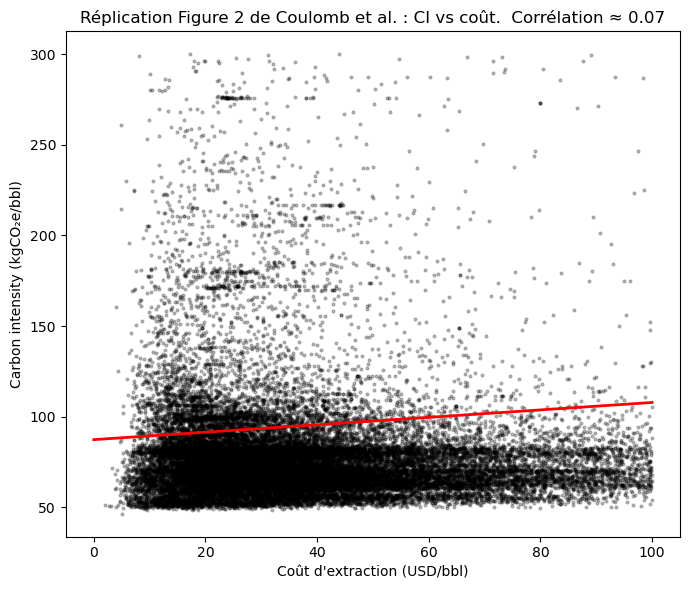

In [28]:
d2 = (ci2[["RE ID", UP, MID]].dropna()
      .assign(CI_comb=lambda x: x[UP] + x[MID])      # kgCO2e/bbl
      .merge(cost, on="RE ID", how="inner")
      .merge(prod_w, on="RE ID", how="left"))
d2 = d2[(d2["CI_comb"] < 300) & d2["cost_bbl"].between(0,100)].dropna(subset=["CI_comb","cost_bbl"])

w = d2["prod_w"].fillna(0).clip(lower=0).to_numpy() + 1e-9
C = np.cov(np.vstack([d2["cost_bbl"], d2["CI_comb"]]), aweights=w)
corr = C[0,1] / np.sqrt(C[0,0]*C[1,1])
b, a = np.polyfit(d2["cost_bbl"], d2["CI_comb"], 1, w=np.sqrt(w))

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(d2["cost_bbl"], d2["CI_comb"], s=4, alpha=.25, color="black")
xs = np.linspace(0,100,50); ax.plot(xs, b*xs+a, "r-", lw=2)
ax.set_xlabel("Coût d'extraction (USD/bbl)")
ax.set_ylabel("Carbon intensity (kgCO₂e/bbl)")
ax.set_title(f"Réplication Figure 2 de Coulomb et al. : CI vs coût.  Corrélation ≈ {corr:.2f}")
plt.tight_layout(); plt.show()

In [29]:
import pandas as pd 
import numpy as np 

df_asset_info = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Asset_Info.csv', encoding='Latin-1',nrows=1000)
df_reserves_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_North_America.csv',  encoding='Latin-1',nrows=1000)
df_reserves_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_Rest.csv', encoding='Latin-1',nrows=1000)
df_production = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Production.csv',  encoding='Latin-1',nrows=1000)
df_eco_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_North_America.csv',  encoding='Latin-1',nrows=1000)
df_eco_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_Rest.csv',  encoding='Latin-1',nrows=1000)
df_Deflator = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Deflator.csv',  encoding='Latin-1',nrows=1000)
df_Carbon_Intensity = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/CI_Full.csv',  encoding='Latin-1',nrows=1000)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rratajczyk/Desktop/OilMarket/repo/Data/Asset_Info.csv'

In [ ]:

print(f"NaN = {df_reserves_rest['Resources (Million bbl)'].isna().sum() / len(df_reserves_rest['Resources (Million bbl)']) * 100:.2f}%")

LoadError: LoadError: UndefVarError: `@f_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X32sZmlsZQ==.jl:2

In [ ]:
df_asset_info.columns

df_reserves_NA.columns

df_production.columns

df_eco_NA.columns 
# CapEx (coût d'investissement dans les infrastructures) et OpEx (coût opératoire d'exploitation) , 
# fiscalité (Royalties=rente à verser à l'Etat, taxe sur la production) et break-even prices (revenue=coût)

#df_Deflator.columns # pour convertir en dollars constants, avec base 2XXX (?)

# redondant avec reserves_NA #df_reserves_rest.columns
# redondant avec eco_NA #df_eco_rest.columns
# méga-gisements au Moyen-Orient versus nombre démesurés de gisements différents aux US, d'où la séparation NA / reste du monde 

UndefVarError: UndefVarError: `df_asset_info` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
path = '/Users/rratajczyk/Desktop/OilMarket/repo/Data/'
datasets= ['Asset_Info.csv', 'Reserves_North_America.csv', 'Reserves_Rest.csv', 'Production.csv', 'Eco_North_America.csv', 'Eco_Rest.csv', 'Deflator.csv']
for p in datasets: 
    print(f"#### {p} ####")
    df = pd.read_csv(f'/Users/rratajczyk/Desktop/OilMarket/repo/Data/{p}',nrows=1000)
    print(df.dtypes)
    print(df.columns)
    print(df.head(2))


Base.Meta.ParseError: ParseError:
# Error @ /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:1:9
path = '/Users/rratajczyk/Desktop/OilMarket/repo/Data/'
#       └────────────────────────────────────────────┘ ── character literal contains multiple characters

In [ ]:
# # clé commune : RE_ID (+Year pour les données de panel)
# df_main = pd.merge(df_prod, df_eco, on=['RE ID', 'Year'], how='inner')

# df_main = pd.merge(df_main, df_asset, on='RE ID', how='left') # peut créer des NaN pour les gisements présents dans prod/eco mais absents de asset_info, à vérifier
# df_main2 = pd.merge(df_main,df_asset,on='RE ID', how='inner') 
# print(df_main.shape, df_main2.shape) 

Base.Meta.ParseError: ParseError:
# Error @ /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl:2:42
# clé commune : RE_ID (+Year pour les données de panel)
df_main = pd.merge(df_prod, df_eco, on=['RE ID', 'Year'], how='inner')
#                                        └───┘ ── character literal contains multiple characters

# julia

Pas des optimisations: des recherches de points fixes de best-responses functions, c'est différent. 
Objectif: valider un solver, on utilise des données jouet, rien de réel.

Rystad entre quand on veut produire des résultats sur le marché du pétrole, mais il faut déjà valider les modèles sur des données rondes faciles à vérifier. Rystad entre en jeu pour un changement d'objectif (production), pas un ajout de couche de compelxité


## Modèle 0

Equilibre de Nash-Cournot STATIQUE (1 periode) : cartel vs frange agregée, avec parametre de collusion theta dans [0,1] (ad-hoc mais peut se microfonder).


ce code: 
C'est UN noeud du DAG, sans coalition, avec 1 periode. Nash-Cournot (pas Stackelberg) : le cartel prend l'offre de la frange comme DONNEE (a son niveau d'equilibre), sans anticiper sa reaction marginale d qf / d qc. Ce terme de reaction = ce qu'ajoute Stackelberg ; il est absent ici, voulu.
theta parametre de collusion exogène, posé au niveau du bloc cartel (comme De Canniere, qui l'assume comme ça, et cite
Reiss et Wolak). 
theta=0 : concurrence ; theta=1 : cartel pur / monopole.
Ici theta est POSé, pas derivé. Sa micro-fondation comme degre de
cooperation phi (Cyert et DeGroot 1973), via theta=(1+phi(N-1))/N, vit dans
le Modele 0' (N joueurs) ; son endogeneisation arrive avec le DAG ?. Dans cette cellule on considère un seul bloc, phi n'a aucun role

Pas encore besoin de Gurobi

FOC cartel : $$p − \theta \beta q^c − c^c = 0$$
Offre frange (price-taker) : $$q^f = (p − c^f)/\gamma^f$$
Demande:
$$p = \alpha − \beta(q^c + q^f).$$

Soluble exactement (avec la forme ad-hoc de theta, mais qui peut se microfonder)
-> le modèle 0 est "parfait" *pour ce qui compte pour lui*: il est exact, minimal, honnête

Le code résout deux fois : par substitution analytique (référence exacte, avec les deux coins KKT : frange évincée si $p < c^f$, et $\theta=0$ traité à part), et par itération de meilleures réponses (le cartel répond à $q^f$, la frange répond au prix, on tourne jusqu'à stabilité, c'est la boucle de De Cannière). 

#### Trois sanity checks : 
* les deux solveurs coïncident; 
* les cas limites $\theta=0$ -> $p=c^c$ (concurrence) et $\theta=1$ -> $q^c=(\alpha−c^c)/2\beta$ (monopole, formes closes connues) ; 
* les monotonies $\theta \uparrow$ =>  p $\uparrow$, $q^c \downarrow$. 

Ces tests sont censés attrapés la plupart des bugs


$\uparrow$

In [ ]:
# Modele 0 




using Printf # affichage formaté

# Parametres.
#  Demande inverse : p = alpha - beta*Q,  Q = qc + qf
#  Cartel (conduite theta) : cout marginal constant cc
#  Frange (price-taker) : offre croissante p = cf + gammaf*qf | ici gammaf>0 c'est un terme artificiel pour éviter que la frange ne dégénère et produise +infini (mais la demande aurait freiné ça?)
#  (SUBSTITUT statique a la rarete de Hotelling)
#  En dynamique, l'offre croissante de la frange emergera
#  de maniere endogène à la rente de rarete et gammaf disparaitra

Base.@kwdef struct Params
    alpha::Float64    # choke price            (USD/bbl)
    beta::Float64     # pente demande inverse  (USD/bbl par unite de Q)
    cc::Float64       # cout marginal cartel   (USD/bbl)
    cf::Float64       # cout marginal frange   (USD/bbl)
    gammaf::Float64   # pente offre frange     (USD/bbl par unite de qf)
    theta::Float64    # conduite dans [0,1] : 0 = concurrence, 1 = cartel pur
end

# le prix mondial : il chute quand l'offre totale Q monte  (hypothèse forte sur la demande ?) 
demand_price(P::Params, Q) = P.alpha - P.beta * Q

# Solveur exact (la référence)
# Deux FOC + la demande, trois inconnues (p, qc, qf) :
#   Cartel : produire +1 baisse le prix sur TOUTE sa production ; il n'en
#     internalise qu'une fraction theta  =>  p - theta*beta*qc - cc = 0. 
#   Frange (price taker) : produit tant que p >= son cout marginal
#     =>  qf = (p - cf)/gammaf
#   derniere equation : p = alpha - beta*(qc + qf).
function solve_analytic(P::Params)
    alpha, beta, cc, cf, gammaf, theta = P.alpha, P.beta, P.cc, P.cf, P.gammaf, P.theta

    # theta = 0 : le cartel renonce a son pouvoir de marche => il vend en concurrence pure, p = cc.
    if theta == 0.0
        p  = cc
        qf = max(0.0, (p - cf) / gammaf)
        qc = (alpha - p) / beta - qf
        return (p = p, qc = qc, qf = qf)   # retourne l'equilibre : prix + qui produit combien
    end

    # Cas general (frange supposée active) : on isole p en injectant les deux FOC dans la demande.
    #   p*(1 + 1/theta + beta/gammaf) = alpha + cc/theta + beta*cf/gammaf
    coef = 1 + 1/theta + beta/gammaf
    rhs  = alpha + cc/theta + beta*cf/gammaf      
    p  = rhs / coef
    qc = (p - cc) / (theta * beta)                # quantite cartel deduite de sa FOC
    qf = (p - cf) / gammaf                         # quantite frange deduite de sa FOC

    # Si la frange produit < 0, c'est qu'elle est sous l'eau (p < cf) : elle sort du marché.
    # on re-resout un cartel seul face a la demande.
    if qf < 0.0
        qc = (alpha - cc) / (beta * (1 + theta))
        qf = 0.0
        p  = alpha - beta * qc
    end
    return (p = p, qc = qc, qf = qf)               # l'equilibre de marche
end

# Solveur par best responses comme De Cannière (double-check)
# Chacun reagit a l'autre jusqu'a ce que plus personne ne bouge = point fixe BR(q*) = equilibre de Nash.
# Si ce solveur et l'analytique donnent la meme chose, c'est bon signe
function solve_bestresponse(P::Params; tol = 1e-12, maxit = 200_000)
    alpha, beta, cc, cf, gammaf, theta = P.alpha, P.beta, P.cc, P.cf, P.gammaf, P.theta
    qf = 0.0
    qc = 0.0
    iters = 0
    for it in 1:maxit
        iters = it
        # meilleure reponse du cartel à l'offre courante de la frange (qf pris comme donnée, Nash)
        qc = max(0.0, (alpha - cc - beta*qf) / (beta * (1 + theta)))
        # meilleure reponse de la frange au prix induit par le cartel
        qf_new = max(0.0, (alpha - beta*qc - cf) / (gammaf + beta))
        if abs(qf_new - qf) < tol            # plus de mouvement => on a atteint l'equilibre
            qf = qf_new
            break
        end
        qf = qf_new
    end
    p = alpha - beta*(qc + qf)               # prix d'equilibre
    return (p = p, qc = qc, qf = qf, iters = iters)
end

# SANITY CHECKS 
function run_sanity_checks()
    println("SANITY CHECKS  Modele 0 (Nash-Cournot statique)")

    alpha, beta, cc, cf, gammaf = 100.0, 1.0, 10.0, 20.0, 2.0   # nombres jouet, closed-forms transparents
    atol = 1e-6

    # (1) Les deux solveurs doivent coincider (analytique == bests-responses)
    println("")
    println("(1) Coherence analytique vs bests-responses (cartel + frange)")
    @printf("    %-6s %-26s %-26s\n", "theta", "analytique (p,qc,qf)", "bests-responses (p,qc,qf)")
    for theta in (0.0, 0.17, 0.5, 1.0)
        P  = Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=theta)
        a  = solve_analytic(P)
        b  = solve_bestresponse(P)
        @printf("    %-6.2f (%6.3f,%6.3f,%6.3f)   (%6.3f,%6.3f,%6.3f)\n",
                theta, a.p, a.qc, a.qf, b.p, b.qc, b.qf)
        # TESTS 
        @assert isapprox(a.p,  b.p;  atol=atol) "analytique differe de BR sur p (theta=$theta)"
        @assert isapprox(a.qc, b.qc; atol=atol) "analytique differe de BR sur qc (theta=$theta)"
        @assert isapprox(a.qf, b.qf; atol=atol) "analytique differe de BR sur qf (theta=$theta)"
    end
    println("    ok : analytique et bests-responses coincident")

    # (2) Les deux cas limites, verifiables a la main
    #   theta=0 => concurrence (p = cout marginal) ; theta=1 => monopole. (teste grossièrement le mécanisme de theta)
    println("")
    println("(2) Cartel pur (frange exclue car cf tres eleve)")
    cf_high = 10_000.0
    P0 = Params(alpha=alpha, beta=beta, cc=cc, cf=cf_high, gammaf=gammaf, theta=0.0)
    P1 = Params(alpha=alpha, beta=beta, cc=cc, cf=cf_high, gammaf=gammaf, theta=1.0)
    s0, s1 = solve_analytic(P0), solve_analytic(P1)

    # TESTS (qui ne doivent pas s'activer, vérification contre résultats calculables à la main)
    @assert isapprox(s0.p,  cc;             atol=atol) "theta=0 : p differe de cc"
    @assert isapprox(s0.qc, (alpha-cc)/beta;     atol=atol) "theta=0 : qc differe de (alpha-cc)/beta"
    @assert isapprox(s1.qc, (alpha-cc)/(2beta);  atol=atol) "theta=1 : qc differe du monopole"
    @assert isapprox(s1.p,  (alpha+cc)/2;        atol=atol) "theta=1 : p differe du monopole"
    @printf("    theta=0 : p=%.3f (=cc), qc=%.3f   |  theta=1 : p=%.3f, qc=%.3f (monopole)\n",
            s0.p, s0.qc, s1.p, s1.qc)
    println("    ok : theta=0 donne la concurrence, theta=1 donne le monopole")

    # (3) Le pouvoir de marche (du cartel) va dans le bon sens : theta monte => production cartel baisse, prix monte (rente de rareté artificiellement haute)
    println("")
    println("(3) Comparatif statique (cartel + frange) : theta monte => p monte et qc baisse")
    thetas = range(0.0, 1.0; length = 11)
    ps  = [solve_analytic(Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=t)).p  for t in thetas]
    qcs = [solve_analytic(Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=t)).qc for t in thetas]
    # TESTS 
    @assert all(diff(ps)  .>= -atol) "p devrait croitre avec theta"
    @assert all(diff(qcs) .<=  atol) "qc devrait decroitre avec theta"
    println("    ok : monotonies correctes")

    println("")
    println("TOUS LES SANITY CHECKS PASSENT")
end

# Demo : un equilibre a theta=0.17 (la conduite estimee par De Canniere par SMM)
function demo_calibree()
    println("")
    println("(demo) Equilibre a theta=0.17, POUR ILLUSTRER (conduite estimee par De Canniere)")
    P = Params(alpha=100.0, beta=1.0, cc=10.0, cf=20.0, gammaf=2.0, theta=0.17)   # params jouet, PAS la calib dynamique
    s = solve_analytic(P)
    @printf("    p=%.3f  qc=%.3f  qf=%.3f  Q=%.3f  (part cartel %.1f%%)\n",
            s.p, s.qc, s.qf, s.qc+s.qf, 100*s.qc/(s.qc+s.qf))
end

run_sanity_checks()
demo_calibree()

# PROCHAINE COUCHE  Nash-Cournot 2 PERIODES (epuisabilite)
#  On introduit les stocks Sc, Sf et la contrainte somme des xt <= S0. La rente
#  de rarete lambda apparait. Test a valider : Hotelling, la rente croit au
#  taux r  =>  (p1 - c)/(p0 - c) = 1 + r  sur tout chemin interieur.
#  à checker : a r -> infini (futur ignoré) on doit retomber sur le statique (modèle 0)

SANITY CHECKS  Modele 0 (Nash-Cournot statique)

(1) Coherence analytique vs bests-responses (cartel + frange)
    theta  analytique (p,qc,qf)       bests-responses (p,qc,qf) 
    0.00   (10.000,90.000, 0.000)   (10.000,90.000, 0.000)
    0.17   (22.869,75.697, 1.434)   (22.869,75.697, 1.434)
    0.50   (37.143,54.286, 8.571)   (37.143,54.286, 8.571)
    1.00   (48.000,38.000,14.000)   (48.000,38.000,14.000)
    ok : analytique et bests-responses coincident

(2) Cartel pur (frange exclue car cf tres eleve)
    theta=0 : p=10.000 (=cc), qc=90.000   |  theta=1 : p=55.000, qc=45.000 (monopole)
    ok : theta=0 donne la concurrence, theta=1 donne le monopole

(3) Comparatif statique (cartel + frange) : theta monte => p monte et qc baisse
    ok : monotonies correctes

TOUS LES SANITY CHECKS PASSENT

(demo) Equilibre a theta=0.17, POUR ILLUSTRER (conduite estimee par De Canniere)
    p=22.869  qc=75.697  qf=1.434  Q=77.131  (part cartel 98.1%)


# Modèle 0': 
Equilibre de Nash Cournot a N gros joueurs strategiques + frange agregee, T=1, avec coefficient de cooperation phi dans [0,1]. Un cran plus général que M0

Chaque joueur i a sa FOC coopérative :
$$(p − c_i) = \beta (q_i + \varphi \times \sum_{j≠i} q_j)$$
Demande $$p = \alpha - \beta(\sum_j q_j + q^f)$$

* $\varphi=1$ redonne le cartel pur ($\theta=1$) pour tout N ;
*  $\varphi=0$ redonne la conduite effective $\theta=1/N$ (le résultat Cournot classique) ; 
* N=1 redonne le monopole quel que soit $\varphi$. 
* + la démo hétérogène : coûts (8, 12, 20) -> le moins cher produit le plus (ordre de mérite)

### Précisions algo
* On exige DEUX solveurs qui se croisent : forme close (systeme lineaire, voir notes dans cahier) comme ORACLE, et best-response comme boucle interne facon De Canniere, et comme dans M0.
* Le Modele 0 (un bloc + theta) est le cas particulier qu'on doit retrouver. modèle 0' contient le modèle 0 (N=1)
### Remarques:
* Ordre de mérite (intrapériode) $\neq$ ordre de Herfindahl (inter-périodes)
* Oligopoles: c'est le cadre général, le cartel en est un cas particulier. Et le DAG exige des joueurs individuels, on ne peut pas détacher d'un bloc homogène. On garde quand même {Cartellistes, Oligopolistes,Frange,Coalition} comme structure in fine? 
* phi = 0  -> chacun pour soi; phi = 1  -> chacun maximise le profit joint = cartel parfait. phi fait donc varier continument de l'oligopole concurrentiel au cartel. Microfondation dans le cas symétrique (pas le cas en général) theta=(1+phi(N-1))/N pour N membres symétriques.
* open-loop differe de closed-loop des que N>1 ET T=> 2 bien sûr (sinon aucune dynamique)




In [ ]:
# Modele 0' 



#   On modelise chaque pays comme un joueur. Qu'ils se coordonnent
#   (cartel) ou se concurrencent (Cournot) devient une question 
#   reglée ici par phi, et plus tard se lira sur le DAG (= qui est-ce qui appartient
#   au cartel). 




using Printf              # affichage formaté
using LinearAlgebra       # resolution du systeme lineaire (\) et conditionnement (cond) pour la forme close

# Parametres. Les gros joueurs sont decrits par un vecteur de couts c
# (heterogeneite = un fait avant tout géologique : Arabie (et moyen orient) pas chere vs Venezuela cher).
#  Demande inverse : p = alpha - beta*Q,  Q = somme des qi + Qf
#  Joueur i (cout ci) : FOC de Cournot avec cooperation phi.
#  Frange (price-taker) : p = cf + gammaf*qf  (gammaf = regularisateur statique qui borne l'offre
#  de la frange ; en dynamique il disparait, remplace par la rente de rarete lambdaf, un SCALAIRE
#  par periode, pas une pente). On prendra coûts constant, hétérogénéités inter-champs
Base.@kwdef struct OligoParams
    alpha::Float64           # choke price            (USD/bbl)
    beta::Float64            # pente demande inverse  (USD/bbl par unite de Q)
    c::Vector{Float64}       # couts marginaux des N gros joueurs (USD/bbl)
    phi::Float64             # cooperation dans [0,1] : 0 = Cournot, 1 = cartel parfait
    cf::Float64              # cout marginal frange   (USD/bbl)
    gammaf::Float64          # pente offre frange     (USD/bbl par unite de qf)
end

# conduite agregee equivalente, pour N joueurs identiques : theta=(1+phi(N-1))/N
theta_equiv(phi, N) = (1 + phi*(N-1)) / N

# le prix mondial 
demand_price(P::OligoParams, Qtot) = P.alpha - P.beta * Qtot


# Solveur en FORME CLOSE (systeme lineaire) 

# A frange ACTIVE, tout l'equilibre est
# la solution d'un systeme lineaire en (q_1,...,q_N, qf). On l'assemble et on
# resout d'un coup avec l'operateur \ : ça sert d'oracle independant pour valider la convergence avec best-response.
#
# Les equations (frange active) qui donnent la forme matricielle: 
#   FOC joueur i :  (p - c_i) - beta*( q_i + phi*sum_{j!=i} q_j ) = 0
#     avec p = alpha - beta*(sum_j q_j + qf). En developpant, la ligne i devient
#     (coefficients sur les inconnues q_1..q_N, qf) :
#       - sur q_i :  2*beta                 (le beta du prix + le beta de l'impact propre)
#       - sur q_j (j!=i) : beta*(1+phi)     (le beta du prix + phi*beta de l'impact coopere)
#       - sur qf : beta
#       = alpha - c_i
#   FOC frange (price-taker) :  p = cf + gammaf*qf, soit
#       alpha - beta*(sum_j q_j) - beta*qf = cf + gammaf*qf
#       -> sur chaque q_j : beta ; sur qf : (beta + gammaf) ; = alpha - cf
#
# CAS SINGULIER (inversion pas possible) (phi=1, N>=2) : a cooperation totale, la ligne i a pour coeffs
#   q_i -> 2*beta  et  q_j -> beta*(1+phi) = 2*beta : TOUTES les lignes des gros
#   joueurs deviennent IDENTIQUES => matrice non inv. 
#   Economiquement, le cartel parfait ne contraint que la production TOTALE Q^C
#   du bloc, pas sa REPARTITION entre membres -> les q_i individuels sont
#   indeterminés. On detecte ce cas par le conditionnement avant de resoudre
#   et on renvoie interior=false, singular=true : l'oracle
#   ne s'applique pas ici, le cas phi=1 est deja valide ailleurs (check (1) via
#   solve_theta sur l'agregat Q^C, o^ p/Q^C/qf sont bien definis).
#
# Regime interieur : ce systeme suppose tous les q_i > 0 et qf > 0. Sinon
# (un joueur cher evince, ou frange sous l'eau) on signale interior=false et
# seul le best-response fait foi.
function solve_oligopoly_linear(P::OligoParams)
    alpha, beta, c, phi, cf, gammaf = P.alpha, P.beta, P.c, P.phi, P.cf, P.gammaf
    N = length(c)
    M = N + 1                                   # inconnues : q_1...q_N puis qf (indice N+1)
    A = zeros(M, M)
    b = zeros(M)
    # les N lignes des gros joueurs
    for i in 1:N
        for j in 1:N
            A[i, j] = (i == j) ? 2*beta : beta*(1 + phi)
        end
        A[i, N+1] = beta                         # coefficient sur qf
        b[i]      = alpha - c[i]
    end
    # la ligne de la frange
    for j in 1:N
        A[N+1, j] = beta
    end
    A[N+1, N+1] = beta + gammaf
    b[N+1]      = alpha - cf

    # anti singularite avant la resolution 
    if cond(A) > 1e12
        return (p = NaN, q = fill(NaN, N), qf = NaN, Qbig = NaN,
                interior = false, singular = true)
    end

    sol = A \ b                                  # inversion (par factorisation LU interne)
    q   = sol[1:N]
    qf  = sol[N+1]
    interior = all(q .> -1e-12) && qf > -1e-12   # le regime interieur est-il valide ?
    q  = max.(q, 0.0)
    qf = max(qf, 0.0)
    p  = alpha - beta*(sum(q) + qf)
    return (p = p, q = q, qf = qf, Qbig = sum(q), interior = interior, singular = false)
end

# Solveur par bests responses
# Chaque gros joueur reagit a tous les autres (gros + frange) ; on tourne
# jusqu'au point fixe ou plus personne ne bouge = equilibre de Nash-Cournot. (convergence intra-période)
# C'est la boucle interne de De Canniere, generalisee a N joueurs.
# NB : a phi=1, il converge vers UNE repartition (arbitraire, car indeterminee),
# mais p, Qbig et qf sont bien definis -> c'est ce qui fait foi dans ce cas.
#
# FOC du joueur i (cooperation phi) :
#   (p - ci) - beta*( qi + phi*somme_{j!=i} qj ) = 0
#   -> le joueur internalise son impact prix sur sa propre
#      production (qi), et une fraction phi de son impact sur celle des autres. 
function solve_oligopoly(P::OligoParams; tol = 1e-12, maxit = 1_000_000)
    alpha, beta, c, phi, cf, gammaf = P.alpha, P.beta, P.c, P.phi, P.cf, P.gammaf
    N = length(c)
    q  = max.((alpha .- c) ./ (beta*(N+2)), 0.0)   # init raisonnable
    qf = 0.0
    iters = 0
    for it in 1:maxit
        iters = it
        qprev = copy(q); qfprev = qf
        # meilleure reponse de chaque gros joueur, l'un apres l'autre
        for i in 1:N
            others = sum(q) - q[i]                  # production des autres gros joueurs
            # alpha - beta(qi+others+qf) - ci - beta(qi + phi*others) = 0   ->   on isole qi
            qi = (alpha - c[i] - beta*others - beta*qf - beta*phi*others) / (2*beta)
            q[i] = max(qi, 0.0)                      # quantite >= 0
        end
        # la frange suit le prix induit par les gros joueurs
        Qbig = sum(q)
        qf = max(0.0, (alpha - beta*Qbig - cf) / (gammaf + beta))
        # convergence : plus personne ne bouge => equilibre atteint
        if maximum(abs.(q .- qprev)) < tol && abs(qf - qfprev) < tol
            break
        end
    end
    p = alpha - beta*(sum(q) + qf)                  # prix d'equilibre
    return (p = p, q = q, qf = qf, Qbig = sum(q), iters = iters)  # l'equilibre complet
end

# Reference Modele 0 (cartel-fringe, 1 bloc, conduite theta) 
function solve_theta(alpha, beta, cc, theta, cf, gammaf)
    if theta == 0.0
        p = cc; qf = max(0.0, (p - cf)/gammaf); return (p=p, qc=(alpha-p)/beta - qf, qf=qf)
    end
    coef = 1 + 1/theta + beta/gammaf
    rhs  = alpha + cc/theta + beta*cf/gammaf
    p = rhs/coef; qc = (p-cc)/(theta*beta); qf = (p-cf)/gammaf
    if qf < 0.0
        qc = (alpha-cc)/(beta*(1+theta)); qf = 0.0; p = alpha - beta*qc
    end
    return (p=p, qc=qc, qf=qf)
end

# SANITY CHECKS : prouver que ce modèle 0' contient le modèle 0 
function run_sanity_checks()
    println("SANITY CHECKS  Modele 0' (oligopole-frange à N joueurs)")
    alpha, beta, cf, gammaf = 100.0, 1.0, 20.0, 2.0
    cc = 10.0
    atol = 1e-6

    # (0) les deux solveurs doivent coincider (forme close == best-response),
    #     exactement comme en M0. On saute le cas singulier phi=1,N>=2 (repartition
    #     individuelle indeterminee : l'oracle lineaire ne s'y applique pas ; ce cas
    #     est valide par le check suivant, (1) ).
    println("")
    println("(0) Coherence forme close (oracle) vs best-response")
    nskip = 0
    for N in (1, 2, 3), phi in (0.0, 0.3, 1.0)
        c = N == 1 ? [12.0] : collect(range(8.0, 20.0; length=N))
        P = OligoParams(alpha=alpha, beta=beta, c=c, phi=phi, cf=cf, gammaf=gammaf)
        lin = solve_oligopoly_linear(P)
        br  = solve_oligopoly(P)
        if lin.singular
            nskip += 1                               # phi=1, N>=2 : repartition indeterminee, on saute
            continue
        end
        if lin.interior                              # oracle fiable seulement en regime interieur
            @assert isapprox(lin.p,    br.p;    atol=atol) "lineaire != BR sur p (N=$N, phi=$phi)"
            @assert isapprox(lin.Qbig, br.Qbig; atol=atol) "lineaire != BR sur Qbig (N=$N, phi=$phi)"
            @assert isapprox(lin.qf,   br.qf;   atol=atol) "lineaire != BR sur qf (N=$N, phi=$phi)"
        end
    end
    @printf("    ok : forme close et best-response coincident (regime interieur ; %d cas phi=1,N>=2 sautes)\n", nskip)

    # (1) phi=1 (coop totale) => cartel pur (theta=1), pour TOUT N
    println("")
    println("(1) N joueurs identiques, phi=1  =  cartel pur du Modele 0 (theta=1)")
    ref1 = solve_theta(alpha, beta, cc, 1.0, cf, gammaf)
    for N in (1, 2, 5)
        P = OligoParams(alpha=alpha, beta=beta, c=fill(cc, N), phi=1.0, cf=cf, gammaf=gammaf)
        s = solve_oligopoly(P)
        @printf("    N=%d : phi=1  p=%.3f  Qc=%.3f  qf=%.3f\n", N, s.p, s.Qbig, s.qf)
        @assert isapprox(s.p,    ref1.p;  atol=atol) "phi=1 differe du cartel sur p (N=$N)"
        @assert isapprox(s.Qbig, ref1.qc; atol=atol) "phi=1 differe du cartel sur Qc (N=$N)"
    end
    println("    ok : phi=1 redonne le cartel pur quel que soit N")

    # (2) phi=0 (Cournot pur) => conduite effective theta=1/N
    println("")
    println("(2) N joueurs identiques, phi=0 (Cournot)  =  theta effectif = 1/N")
    for N in (1, 2, 3, 10)
        P   = OligoParams(alpha=alpha, beta=beta, c=fill(cc, N), phi=0.0, cf=cf, gammaf=gammaf)
        s   = solve_oligopoly(P)
        ref = solve_theta(alpha, beta, cc, theta_equiv(0.0, N), cf, gammaf)  # theta=1/N
        @printf("    N=%2d : phi=0  p=%.3f  Qc=%.3f   |  theta=1/N=%.3f  p=%.3f  Qc=%.3f\n",
                N, s.p, s.Qbig, 1/N, ref.p, ref.qc)
        @assert isapprox(s.p,    ref.p;  atol=atol) "phi=0 differe de theta=1/N sur p (N=$N)"
        @assert isapprox(s.Qbig, ref.qc; atol=atol) "phi=0 differe de theta=1/N sur Qc (N=$N)"
    end
    println("    ok : phi=0 redonne la conduite effective 1/N")

    # (3) N=1 => monopole, quel que soit phi (un seul joueur n'a personne avec qui coopérer)
    println("")
    println("(3) N=1 : monopole (theta=1) quel que soit phi")
    cf_high = 10_000.0   # frange exclue pour isoler le monopole
    for phi in (0.0, 0.5, 1.0)
        P = OligoParams(alpha=alpha, beta=beta, c=[cc], phi=phi, cf=cf_high, gammaf=gammaf)
        s = solve_oligopoly(P)
        @assert isapprox(s.q[1], (alpha-cc)/(2beta); atol=atol) "N=1 : q differe du monopole (phi=$phi)"
        @assert isapprox(s.p,    (alpha+cc)/2;       atol=atol) "N=1 : p differe du monopole (phi=$phi)"
    end
    println("    ok : N=1 redonne le monopole pour tout phi")

    println("")
    println("TOUS LES SANITY CHECKS PASSENT  (le Modele 0' contient bien le Modele 0)")
end

# Demo : 3 gros joueurs hétérogènes (le cas realiste, impossible avec un theta unique)
function demo_heterogene()
    println("")
    println("(demo) 3 gros joueurs hétérogènes (couts 8, 12, 20), phi=0.3")
    P = OligoParams(alpha=100.0, beta=1.0, c=[8.0, 12.0, 20.0], phi=0.3, cf=20.0, gammaf=2.0)
    s = solve_oligopoly(P)
    @printf("    p=%.3f   q=[%.3f, %.3f, %.3f]   qf=%.3f\n", s.p, s.q[1], s.q[2], s.q[3], s.qf)
    #@printf("    theta effectif equivalent (si identiques) = %.3f\n", theta_equiv(0.3, 3))
    println("    le moins cher produit le plus : ordre respecté.")
    
end

run_sanity_checks()
demo_heterogene()

# SUITE  ==>  M1 (T=2, DEQN) puis M2 (T long, DEQN, oracle DP?)
#  Dynamique : une Bellman par gros joueur (stocks Si), frange inchangee ;
#    rente de Hotelling, effet de sequence. Etat de dimension N+1 



SANITY CHECKS  Modele 0' (oligopole-frange à N joueurs)

(1) N joueurs identiques, phi=1  ==  cartel pur du Modele 0 (theta=1)
    N=1 : phi=1  p=48.000  Qc=38.000  qf=14.000
    N=2 : phi=1  p=48.000  Qc=38.000  qf=14.000
    N=5 : phi=1  p=48.000  Qc=38.000  qf=14.000
    ok : phi=1 redonne le cartel pur quel que soit N

(2) N joueurs identiques, phi=0 (Cournot)  ==  theta effectif = 1/N
    N= 1 : phi=0  p=48.000  Qc=38.000   |  theta=1/N=1.000  p=48.000  Qc=38.000
    N= 2 : phi=0  p=37.143  Qc=54.286   |  theta=1/N=0.500  p=37.143  Qc=54.286
    N= 3 : phi=0  p=31.111  Qc=63.333   |  theta=1/N=0.333  p=31.111  Qc=63.333
    N=10 : phi=0  p=18.182  Qc=81.818   |  theta=1/N=0.100  p=18.182  Qc=81.818
    ok : phi=0 redonne la conduite effective 1/N

(3) N=1 : monopole (theta=1) quel que soit phi
    ok : N=1 redonne le monopole pour tout phi

TOUS LES SANITY CHECKS PASSENT  (le Modele 0' contient bien le Modele 0)

(demo) 3 gros joueurs hétérogènes (couts 8, 12, 20), phi=0.3
    p=4

In [ ]:
# Modele M1 

# cartel-frange, T=2, rente de Hotelling, premier DEQN


# Un joueur strategique (cartel) + frange
# price-taker, deux periodes. Ici closed-loop = open-loop (un seul strategique,
# Kellogg 2024), donc la solution analytique open-loop EST le MPE 
# Le but de cette couche de complex :  prmeiere architecture DEQN finale ; ancrage terminal (1-tau) ; clamp aux coins ; deux forwards,
# un backprop, contre un oracle analytique.

# Python PyTorch 


import numpy as np
import torch, torch.nn as nn
import time

torch.set_default_dtype(torch.float64)   # précision cible exige
torch.manual_seed(0); np.random.seed(0)

# STEP 0  parametres

alpha, beta = 100.0, 1.0        # demande inverse p = alpha - beta*Q
cc, cf = 10.0, 20.0             # couts marginaux cartel / frange
r = 0.05; delta = 1.0/(1.0+r)   # actualisation
Sc0, Sf0 = 30.0, 20.0           # stocks initiaux (petits => rarete mord, rentes > 0)
kappa = 1e6                     # capacite (non active ici car énorme)
bstop = 1e6                     # backstop (non active ici car énorme) # pourquoi les coder alors: car ce code est déjà celui de M2, on les activera
T = 2
VREF = alpha*Sc0                # echelles pour normaliser les residus
LREF = alpha

# STEP 1  verite analytique : systeme 4x4 du regime interieur/epuisement (on confrontera les résultats de STEP 1 au réseau)



# Les 4 equations : Hotelling frange (p-cf croit au taux r), Hotelling cartel
# (la MR nette p - beta*xc - cc croit au taux r), epuisement des deux stocks.
# Lineaire => forme close, meme méthode qu'en M0'.
A4 = np.array([
    [-beta,        delta*beta, -beta,  delta*beta], # ligne FRANGE : p0​−cf​= \delta (p1​−cf​) (indiferrence), injecter demande. 
    [-2*beta,    2*delta*beta, -beta,  delta*beta], # ligne CARTEL : p0​−\beta xc0​−cc​= \delta (p1​−\beta xc1​−cc​), injecter demande.
    [1.0, 1.0, 0.0, 0.0], # epuisement cartel x_c0 + x_c1 = S_c0 
    [0.0, 0.0, 1.0, 1.0]]) # epsuisement frange x_f0 + x_f1 = S_f0

b4 = np.array([-(alpha-cf)*(1-delta), -(alpha-cc)*(1-delta), Sc0, Sf0])
xc0a, xc1a, xf0a, xf1a = np.linalg.solve(A4, b4)
p0a = alpha - beta*(xc0a+xf0a); p1a = alpha - beta*(xc1a+xf1a)

# oracle independant : point fixe de best-responses en trajectoires
# (le cartel resout son programme 2 periodes a trajectoire de frange donnee ;
#  la frange arbitre p0-cf = delta*(p1-cf) a trajectoire de cartel donnee) 

# /!!!\ (open-loop = closed-loop car un seul joueur strategique)

def cartel_br(yf0, yf1, S):
    u0 = (alpha - beta*yf0 - cc)/(2*beta); u1 = (alpha - beta*yf1 - cc)/(2*beta)
    if u0 + u1 <= S: return max(u0,0.0), max(u1,0.0)       # rarete ne mord pas
    x0 = ((alpha-cc)*(1-delta) - beta*yf0 + delta*beta*yf1 + 2*delta*beta*S)/(2*beta*(1+delta))
    x0 = min(max(x0,0.0),S); return x0, S-x0
def fringe_arb(yc0, yc1, S):
    v0 = (alpha - beta*yc0 - cf)/beta; v1 = (alpha - beta*yc1 - cf)/beta
    if max(v0,0)+max(v1,0) <= S: return max(v0,0.0), max(v1,0.0)
    x0 = ((1-delta)*(alpha-cf) - beta*yc0 + delta*beta*yc1 + delta*beta*S)/(beta*(1+delta))
    x0 = min(max(x0,0.0),S); return x0, S-x0
yc0,yc1,yf0,yf1 = 5.,5.,5.,5.
for _ in range(200000):
    nc0,nc1 = cartel_br(yf0,yf1,Sc0); nf0,nf1 = fringe_arb(nc0,nc1,Sf0)
    if max(abs(nc0-yc0),abs(nc1-yc1),abs(nf0-yf0),abs(nf1-yf1)) < 1e-13: break
    yc0,yc1,yf0,yf1 = nc0,nc1,nf0,nf1

# assertions sur la "vérité" (regime + croisement des deux solveurs)
assert min(xc0a,xc1a,xf0a,xf1a) > 0, "regime interieur violé"
assert abs((p0a-cf) - delta*(p1a-cf)) < 1e-9, "Hotelling frange violé"
assert abs((p0a-beta*xc0a-cc) - delta*(p1a-beta*xc1a-cc)) < 1e-9, "Hotelling cartel violé"
assert max(abs(yc0-xc0a),abs(yc1-xc1a),abs(yf0-xf0a),abs(yf1-xf1a)) < 1e-9, "4x4 != best-response"
print(f"STEP 1 ok : verite analytique OK et croisée, à 10-9 près")
print(f"  Print des trajectoires : xc=({xc0a:.4f},{xc1a:.4f}) xf=({xf0a:.4f},{xf1a:.4f}) p=({p0a:.4f},{p1a:.4f})")

# STEP 2  reseaux : un par agent, trois tetes chacun
# tete z -> politique x = min(S,kappa)*sigmoid(z)  (faisabilité par architecture)
# tete w -> valeur V = (1-tau)*w*VREF              (ancrage terminal par architecture)
# tete l -> co-etat lambda = (1-tau)*softplus(l)*LREF  (rente >= 0, ancrée a 0 en tau=1) 
# (rappel co-état = dV/dS). et on a besoin de V ET de lambda, car la tête contrôle V en niveau, pas ses dérivées

# La FOC consomme la tete co-etat ; la tete valeur (Bellman) est l'element d'architecture pour M3, où son gradient deviendra porteur.

class Net(nn.Module):
    def __init__(s, width=96):
        super().__init__()
        s.trunk = nn.Sequential(nn.Linear(3,width), nn.SiLU(), nn.Linear(width,width), nn.SiLU()) 
        # SiLU(x) = x·sigmoide(x) = x/(1+exp(-x)) ressemble à ReLU pour |x| grand. Lisse partout, C^infty, pour pouvoir la dériver. 
        # Reste à tester ReLU versus SiLU. 
        s.head_z = nn.Linear(width,1); s.head_w = nn.Linear(width,1); s.head_l = nn.Linear(width,1)
    def forward(s, sc, sf, tau):
        h = s.trunk(torch.stack([sc/Sc0, sf/Sf0, tau], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

netc, netf = Net(), Net()

def forward_all(sc, sf, tau):
    zc, wc, lc_raw = netc(sc, sf, tau); zf, wf, lf_raw = netf(sc, sf, tau)
    xc = torch.minimum(sc, torch.tensor(kappa))*torch.sigmoid(zc)
    xf = torch.minimum(sf, torch.tensor(kappa))*torch.sigmoid(zf)
    Vc = (1.0-tau)*wc*VREF
    lc = (1.0-tau)*torch.nn.functional.softplus(lc_raw)*LREF
    lf = (1.0-tau)*torch.nn.functional.softplus(lf_raw)*LREF
    return xc, xf, Vc, lc, lf

# STEP 3  residus : le coeur du DEQN
# Deux forwards (t puis t+1, memes reseaux), un backprop sur le graphe de calcuk entier.

def residuals(sc, sf, t):
    tau = t/T; tau2 = (t+1)/T
    xc, xf, Vc, lc, lf = forward_all(sc, sf, tau)                 # forward 1
    p = torch.minimum(alpha - beta*(xc+xf), torch.tensor(bstop))  # backstop cote marche
    sc2, sf2 = sc-xc, sf-xf                                       # transition d'etat
    _,_,Vc2, lc2, lf2 = forward_all(sc2, sf2, tau2)               # forward 2, memes poids
    hc = p - beta*xc - cc - delta*lc2                             # profitabilite marginale cartel
    Rc_foc  = xc - torch.clamp(xc + hc/(2*beta), torch.zeros_like(xc), torch.minimum(sc, torch.tensor(kappa))) # torch.clamp borne x dans [a,b]
    Rc_env  = lc - torch.maximum(p - beta*xc - cc, delta*lc2)     # recursion co-etat cartel ; la valeur marginale d'un baril aujourd'hui est le meilleur de deux options
    Rc_bell = Vc - ((p-cc)*xc + delta*Vc2)                        # Bellman (tete valeur)
    hf = p - cf - delta*lf2                                       # profitabilite marginale frange
    Rf_foc = xf - torch.clamp(xf + hf/beta, torch.zeros_like(xf), torch.minimum(sf, torch.tensor(kappa)))
    Rf_env = lf - torch.maximum(p - cf, delta*lf2)                # recursion co-etat frange ; la valeur marginale d'un baril aujourd'hui est le meilleur de deux options
    return Rc_foc, Rc_env, Rc_bell, Rf_foc, Rf_env

def loss_from_res(R):
    Rc_foc, Rc_env, Rc_bell, Rf_foc, Rf_env = R
    # somme des carres normalises : quantites en unites de stock, co-etats en
    # unites de choke price, valeur en unites de alpha*S0. Poids égaux : sinon on donnerait injustement du poids à des termes de la loss
    return ((Rc_foc/Sc0)**2 + (Rc_env/LREF)**2 + (Rc_bell/VREF)**2
            + (Rf_foc/Sf0)**2 + (Rf_env/LREF)**2).mean()

# choix d'echantillonnage important : tirage uniforme sur la boite
# élargie à 1.15*S0 (sinon l'etat initial est un coin de mesure nulle et résidus qui y vivent pèsent zéro dans la loss moyenne).
# Surtout: le coin est sur la frontière de l'entraînement. Le réseau n'a aucun point "au-delà" pour interpoler ; il extrapole. 
# Or l'extrapolation est précisément ce qu'un réseau fait très mal.

# Élargir à 1,15 rend S0 strictement intérieur : le réseau peut interpoler, S0 est entouré de points. 
# C'est un pur artifice numérique, et les états au-delà de S0 sont inatteignables (stock ne pouvant que décroitre par hypothèse de non-développement non-discovery)
# c'est un prix à payer, mais il est donc faible

def sample_states(B):
    B1 = B//2 # batch coupé en deux moitiés, de distributions différentes 
    sc_u = torch.rand(B1)*Sc0*1.15; sf_u = torch.rand(B1)*Sf0*1.15 # tirage uniforme sur la boite élargie
    t_u  = torch.randint(0, T, (B1,)).double()
    with torch.no_grad():
        # on tire des stocks de départ hauts, on fait tourner la politique courante dessus (forward_all(sc0, sf0, tau=0)), 
        # et on garde les états d'arrivée sc1 = sc0 - xc0. 
        # Ce sont des états engendrés par la politique, donc leur distribution n'est pas uniforme : 
        # elle est concentrée là où les trajectoires passent réellement. 
        m = (B-B1)//2
        sc0 = (0.5+0.65*torch.rand(m))*Sc0; sf0 = (0.5+0.65*torch.rand(m))*Sf0
        xc0,xf0,_,_,_ = forward_all(sc0, sf0, torch.zeros(m))
        sc1, sf1 = sc0-xc0, sf0-xf0
    return (torch.cat([sc_u, sc0, sc1]), torch.cat([sf_u, sf0, sf1]),
            torch.cat([t_u, torch.zeros(m), torch.ones(m)]))

# STEP 4  entrainement : stochastique GD,  puis L-BFGS (finisseur batch complet)
print("STEP 4 : entrainement Adam...")
opt = torch.optim.Adam(list(netc.parameters())+list(netf.parameters()), lr=1e-3)
t0 = time.time()
for it in range(8000):
    if it == 5000:
        for g in opt.param_groups: g['lr'] = 2e-4
    opt.zero_grad()
    L = loss_from_res(residuals(*sample_states(512)))
    L.backward(); opt.step()
    if it % 2000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)

print("STEP 4 : finisseur L-BFGS (collocation fixe, batch complet)...")
for outer in range(2):
    sc, sf, t = sample_states(6000)
    sc = torch.cat([sc, torch.full((100,),Sc0)]); sf = torch.cat([sf, torch.full((100,),Sf0)])
    t  = torch.cat([t, torch.zeros(100)])          # ancre l'etat initial dans le jeu fixe
    opt2 = torch.optim.LBFGS(list(netc.parameters())+list(netf.parameters()), lr=1.0, 
                             max_iter=200, history_size=60, tolerance_grad=1e-15,
                             tolerance_change=1e-16, line_search_fn='strong_wolfe')
    # Limited-memory BFGS (Broyden–Fletcher–Goldfarb–Shanno). 
# Méthode quasi-Newton optimisée, qui stocke l'historique ici des 60 dernières paires (pas,changement de gradient) 
# pour mieux suivre la courbe de la loss
# L-BFGS vient préciser Adam au fond des puits, elle ne le remplace pas 
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(sc, sf, t)); Lf.backward(); return Lf
    L = opt2.step(closure)
    print(f"  outer={outer} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)

# STEP 5  rollout et validation contre l'analytique
# le reseau n'a jamais vu de trajectoire : on deroule S0 -> x -> S1 -> x1
def rollout():
    sc = torch.tensor([Sc0]); sf = torch.tensor([Sf0]); out=[]
    with torch.no_grad():
        for tt in range(T):
            tau = torch.tensor([tt/T])
            xc, xf, _,_,_ = forward_all(sc, sf, tau)
            p = alpha - beta*(xc+xf)
            out.append((xc.item(), xf.item(), p.item()))
            sc, sf = sc-xc, sf-xf
    return out, sc.item(), sf.item()

traj, scT, sfT = rollout()
ana = [(xc0a, xf0a, p0a), (xc1a, xf1a, p1a)]
print("\n t | reseau (xc, xf, p)               | analytique")
maxrel = 0.0
for tt in range(T):
    for k in range(3): maxrel = max(maxrel, abs(traj[tt][k]-ana[tt][k])/abs(ana[tt][k]))
    print(f" {tt} | ({traj[tt][0]:8.4f},{traj[tt][1]:8.4f},{traj[tt][2]:8.4f}) | ({ana[tt][0]:8.4f},{ana[tt][1]:8.4f},{ana[tt][2]:8.4f})")
print(f"stocks residuels : Sc={scT:.4f} Sf={sfT:.4f} (epuisement attendu)")
print(f"erreur relative max trajectoire = {maxrel:.2e}")

# diagnostic sévère : residu FOC maximal en $/bbl sur une grille test
g = torch.linspace(0.05, 1.10, 25)
SCg, SFg = torch.meshgrid(g*Sc0, g*Sf0, indexing='ij')
with torch.no_grad():
    for tt in (0.0, 1.0):
        R = residuals(SCg.reshape(-1), SFg.reshape(-1), torch.full((625,), tt))
        print(f"residu max (t={int(tt)}) : FOCc={2*beta*R[0].abs().max():.3f} $/bbl  FOCf={beta*R[3].abs().max():.3f} $/bbl  env_c={R[1].abs().max():.3f}  env_f={R[4].abs().max():.3f}")

# tolerance : 5e-2 atteint et assuré ;  1e-3 exige de lever
# l'inconsistance hors sentier : soit systeme d'Euler
# pur (exact a un strategique seulement...), soit co-etats croises
# complets (le M3). Decision a M2/M3

assert maxrel < 5e-2, f"trajectoire reseau trop loin de l'analytique : {maxrel:.2e}"
print("\nVALIDATION M1 OK (tolerance 1e-2 ; faire de la précision un critère pour M2/M3)")

STEP 1 ok : verite analytique OK et croisée, à 10-9 près
  Print des trajectoires : xc=(14.8780,15.1220) xf=(11.4634,8.5366) p=(73.6585,76.3415)
STEP 4 : entrainement Adam...
  it=    0 loss=3.986e-01 (0s)
  it= 2000 loss=2.489e-04 (11s)
  it= 4000 loss=1.691e-04 (21s)
  it= 6000 loss=7.282e-05 (32s)
STEP 4 : finisseur L-BFGS (collocation fixe, batch complet)...
  outer=0 loss=6.751e-05 (49s)
  outer=1 loss=3.789e-05 (55s)

 t | reseau (xc, xf, p)               | analytique
 0 | ( 14.7143, 11.7529, 73.5329) | ( 14.8780, 11.4634, 73.6585)
 1 | ( 15.2763,  8.2426, 76.4811) | ( 15.1220,  8.5366, 76.3415)
stocks residuels : Sc=0.0094 Sf=0.0045 (epuisement attendu)
erreur relative max trajectoire = 3.44e-02
residu max (t=0) : FOCc=0.935 $/bbl  FOCf=0.530 $/bbl  env_c=0.339  env_f=1.249
residu max (t=1) : FOCc=0.183 $/bbl  FOCf=0.037 $/bbl  env_c=3.038  env_f=2.333

VALIDATION M1 OK (tolerance 1e-2 ; faire de la précision un critère pour M2/M3)


# Commentaires (en cours)

* choix architectures
* écrire les résidus et les FOC 
* tirage est un mélange de deux distributions
* Adam et L_BFGS



### notes Code Modele_V2 Léo 

minimise coûts d'extraction + coût carbone taxé + coûts d'investissement − surplus du consommateur sur tout champ i et tout temps t ; contraintes réserves avec taux de déclin, capacité-plateau proportionnelle au niveau de développement (avec délai LAD entre investissement et production, et dépréciation du capital), niveau de développement borné, demande iso-élastique (élasticité croissant de 0,1 à 0,6), année de découverte.


Pas joueur stratégique, pas de theta, pas de cartel, pas de coalition .
avec la taxe = SCC, Léo donne l'optimum social
Il répond à la question que se passe-t-il si la cartellisation est empêchée ? c'est un équilibre concurrentiel, c'est le noeud entièrement décartellisé de notre DAG ?

In [ ]:
#   code première version dynamique T=2, oligopole-frange N+1 joueurs, 
#   coefficient de coopération phi microfondé, gammaf disparait déjà? coûts constants, hétérogénéités interchamps? 
#   tester open-loop nash cournot vs closed loop stackelberg, le deuxième est il solvable déjà? 

# maintenant, on a un stock fini S0, et garder un baril sous terre devient une valeur (un baril aujourd'hui, c'est un baril de moins demain.)
#   -> rente de rareté lambda émerge et règle de Hotelling
#   -> backward induction de Bellman (résoudre la FOC T=2 avec le stock restant, comme modèle 1, )

#   premières conclusions: 
# - on retrouve modèles 0 et 0' quand r->infty, règle de Hotelling satisfaite (maintenant c'est dynamique, la rente de rareté émerge), 
# et si S0 tend vers +infini la rente de rareté tend vers zéro. 
# - effet de séquence, 
# - 


using Printf

base@